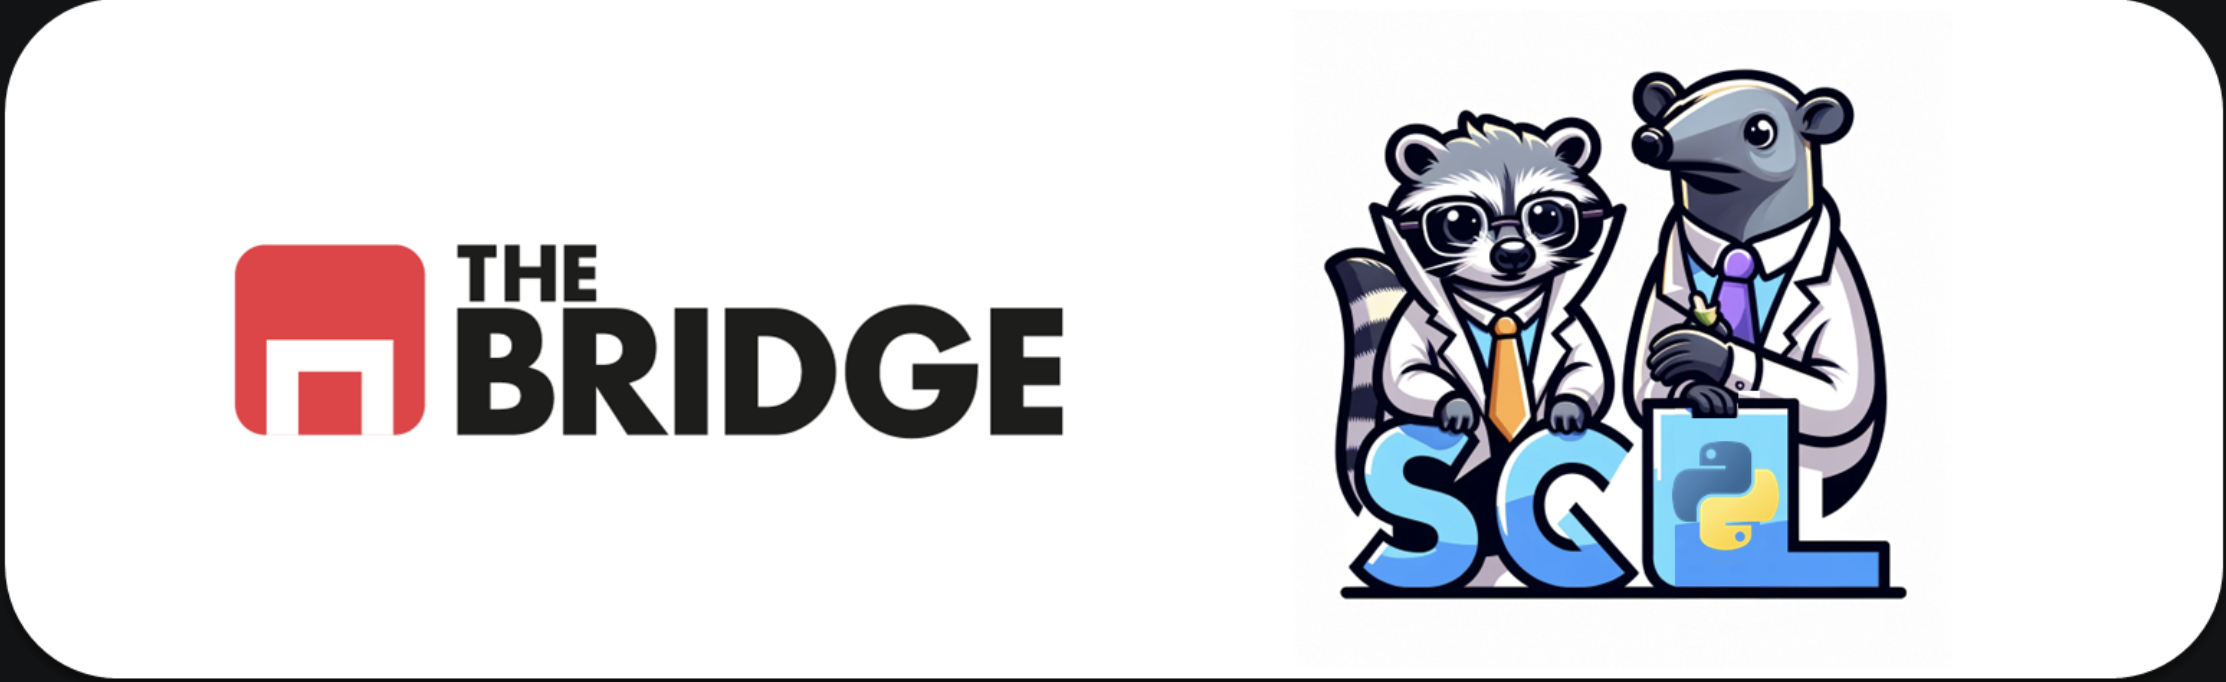

# Team Challenge – SQL
## ```Tu empresa``` — Diseño e implementación de base de datos

---

### Introducción

En esta entrega vais a diseñar e implementar desde cero una base de datos relacional completa para **Tu empresa** (elige tu empresa), un e-commerce de electrónica y accesorios tecnológicos.

Aplicaréis normalización hasta **3NF**, diseñaréis el modelo entidad-relación, lo implementaréis en **Google BigQuery** y lo poblaréis con datos usando Python.

Tendréis que manejaros con **entornos virtuales**, trabajar en equipo usando **Git con feature branches y Pull Requests**, y documentar todo el proceso.

**La entrega deberá constar de:**
- Diagrama ER en formato imagen
- Notebook(s) de Python con todo el código de creación y carga
- Documentación del modelo y decisiones de diseño
- Repositorio de GitHub con estructura correcta

---

### El problema de negocio

**Tu empresa** es un e-commerce que vende productos de tecnología (smartphones, laptops, periféricos, wearables, etc.) en varios países de Europa.

Actualmente operan con hojas de cálculo y exports de CSV dispersos. Necesitan una base de datos centralizada que les permita:

**Control operativo:**
- Gestionar el catálogo de productos por categorías
- Registrar pedidos con sus líneas de producto
- Controlar estados de envío (pending, shipped, delivered, etc.)
- Gestionar pagos y detectar incidencias (reembolsos, pendientes)

**Análisis del negocio:**
- Conocer qué clientes compran qué productos
- Calcular ingresos, márgenes y rentabilidad por categoría
- Segmentar clientes por país y canal de adquisición
- Medir satisfacción mediante valoraciones de productos
- Identificar tendencias temporales de ventas

Vuestro objetivo es diseñar un modelo de datos que soporte estas necesidades de negocio.

---

### Entidades del modelo

El modelo debe incluir **como mínimo** estas entidades. Vosotros debéis decidir qué campos incluye cada una, qué tipos de dato usar, y cómo relacionarlas.

#### Entidades obligatorias:

**1. Clientes (`customers`)**
- Información básica de contacto de los clientes
- País y ciudad (para análisis geográfico)
- Canal por el que nos conocieron (organic, paid ads, redes sociales, etc.)
- Fecha de registro

**2. Categorías de producto (`categories`)**
- Clasificación de los productos (ej: Smartphones, Laptops, Audio, etc.)
- Nombre y descripción

**3. Productos (`products`)**
- Catálogo de productos disponibles
- Debe estar relacionado con categoríasx
- Incluir precio de venta **y** coste (necesario para calcular margen)
- Stock disponible
- Estado activo/inactivo

**4. Pedidos (`orders`)**
- Pedidos realizados por clientes
- Estado del pedido (pending, confirmed, shipped, delivered, cancelled, returned)
- Información de envío
- Fechas relevantes (pedido, envío, entrega)

**5. Líneas de pedido (`order_items`)**
- Detalle de productos incluidos en cada pedido
- Relación entre pedidos y productos (tabla de unión)
- Cantidad de cada producto
- **Precio en el momento de la compra** (importante: puede diferir del precio actual)
- Descuentos aplicados

**6. Pagos (`payments`)**
- Información de pago de cada pedido
- Método de pago utilizado
- Estado del pago (completado, reembolsado, pendiente, fallido)
- Importe y fecha

**7. Valoraciones (`reviews`)**
- Opiniones de clientes sobre productos comprados
- Relacionado con las líneas de pedido (no con el pedido completo)
- Rating numérico y comentario opcional

**Pregunta clave para el diseño:** ¿Qué relación hay entre pedidos y productos? ¿Es directa o necesitáis una tabla intermedia? ¿Por qué?

---

### Normalización — Tercera Forma Normal (3NF)

El modelo debe estar normalizado hasta **3NF**. En vuestro notebook o documentación debéis justificar que se cumplen las tres formas normales:

**1NF — Primera Forma Normal**
- Todos los atributos deben ser atómicos (no listas ni valores múltiples)
- No debe haber grupos repetidos

**2NF — Segunda Forma Normal**
- Debe cumplir 1NF
- No debe haber dependencias parciales (todos los atributos no-clave deben depender de la clave primaria completa, no solo de parte de ella)
- Esto es especialmente relevante en tablas con clave compuesta

**3NF — Tercera Forma Normal**
- Debe cumplir 2NF
- No debe haber dependencias transitivas (ningún atributo no-clave puede depender de otro atributo no-clave)

**Ejemplos de decisiones a justificar:**
- ¿Por qué `unit_price` está en `order_items` y no se lee directamente de `products.price`?
- ¿Por qué `country` está directamente en `customers` y no es una tabla `countries` separada?
- Si en `orders` almacenásemos el nombre del cliente (`customer_name`) además de `customer_id`, ¿qué forma normal se violaría y por qué?

---

### Desarrollo técnico

Tendréis que construir lo siguiente:

**1. Diagrama Entidad-Relación**
- Crear un diagrama ER completo del modelo
- Debe mostrar todas las tablas con sus campos y tipos de dato
- Debe indicar claramente PKs, FKs y cardinalidades (1:N, N:M, etc.)
- Formato: imagen PNG o PDF
- Ubicación en el repo: `docs/er_diagram.png`

Herramientas recomendadas:
- [dbdiagram.io](https://dbdiagram.io) — define el modelo con código y exporta imagen
- [draw.io](https://app.diagrams.net) — editor visual completo
- [Excalidraw](https://excalidraw.com) — colaboración en tiempo real

**2. Implementación en BigQuery**
- Crear el dataset en BigQuery
- Definir los esquemas de las tablas con tipos de dato correctos
- Crear las tablas en el orden correcto (respetando dependencias FK)

**3. Ingesta de datos**
- Busca la forma de conseguir datos realistas
- Generar un volumen mínimo de:
  - 500 clientes
  - 70 productos
  - 2000 pedidos
  - ~4500 líneas de pedido (media 2-3 productos por pedido)
  - Pagos correspondientes a cada pedido
  - Valoraciones para ~35% de los productos entregados
- Los datos deben tener sentido de negocio (precios coherentes, fechas ordenadas, etc.)

**4. Carga de datos en BigQuery**
- Implementar funciones para cargar cada tabla desde DataFrames
- Manejar errores y validar que la carga fue exitosa

**5. Queries de verificación**
- Escribir al menos 5 queries analíticas que demuestren que el modelo funciona
- Ejemplos: ingresos por mes, productos más vendidos, clientes por país, tiempo medio de entrega, etc.

---

### Stack tecnológico

**Obligatorio:**
- **Python**
- **Google BigQuery** — base de datos (requiere cuenta GCP)
- **Entornos virtuales** con `venv`
- **Git + GitHub** — control de versiones
- **Jupyter Notebooks** — desarrollo y documentación

**Librerías Python necesarias:**
```
google-cloud-bigquery
google-auth
db-dtypes
pandas
faker
python-dotenv
pyarrow
```

Todas estas librerías deben estar listadas en `requirements.txt` en la raíz del proyecto.

---

### Estructura del repositorio

El repositorio debe seguir esta estructura:

```
tc-sql-tu_empresa/
├── data/
│   └── (vacío — los datos están en BigQuery)
├── docs/
│   ├── er_diagram.png
│   └── normalizacion.md  (opcional)
├── notebooks/
│   ├── 01_setup_bigquery.ipynb
│   ├── 02_generate_data.ipynb
│   └── 03_queries_verification.ipynb
├── .env.example
├── .gitignore
├── README.md
└── requirements.txt
```

**Importante:**
- El fichero `.env` con credenciales **nunca** se sube al repositorio
- La carpeta `venv/` debe estar en `.gitignore`
- Subid `.env.example` como plantilla sin credenciales reales

---

### Flujo de trabajo Git

**Se debe seguir el flujo simplificado con feature branches y Pull Requests:**

1. **Scrum master crea el repositorio** y añade al resto como colaboradores
2. **Proteger la rama `main`** desde el principio:
   - Settings → Branches → Add rule
   - Require pull request before merging
   - Require 1 approval
3. **Cada integrante trabaja en su propia rama** de feature:
   - `feature/er-diagram-[nombre]`
   - `feature/bigquery-setup-[nombre]`
   - `feature/data-generation-[nombre]`
   - `feature/queries-[nombre]`
4. **Commits con formato Conventional Commits**:
   - `feat: crear esquema de tabla customers`
   - `fix: corregir FK de order_items`
   - `docs: añadir justificación de 3NF`
5. **Abrir Pull Request** cuando la funcionalidad esté lista
6. **Code review** por otro integrante del equipo
7. **Merge con Squash and Merge** para mantener el historial limpio
8. **Sincronizar `main`** localmente tras cada merge:
   ```bash
   git checkout main
   git pull origin main
   ```

**Consultad la guía completa de Git en el fichero HTML adjunto.**

---

### Entornos virtuales

**Cada integrante debe trabajar en un entorno virtual aislado.**

Desde la raíz del proyecto:

```bash
# Crear el entorno virtual
python -m venv venv

# Activarlo
source venv/bin/activate        # Mac/Linux
venv\Scripts\activate           # Windows

# Instalar dependencias
pip install -r requirements.txt

# Verificar instalación
pip list
```

**Reglas importantes:**
- El entorno virtual `venv/` **nunca** se sube al repositorio (debe estar en `.gitignore`)
- Si añadís una librería nueva, actualizad `requirements.txt`:
  ```bash
  pip freeze > requirements.txt
  ```
- Cada vez que otro compañero añada dependencias, ejecutad:
  ```bash
  pip install -r requirements.txt
  ```

**Consultad la guía completa de entornos virtuales en el fichero HTML adjunto.**

---

### Credenciales de Google Cloud

**Configuración de la cuenta GCP:**

1. **Crear un proyecto en Google Cloud** (uno por equipo es suficiente)
2. **Activar la API de BigQuery** en el proyecto
3. **Crear un Service Account:**
   - IAM & Admin → Service Accounts → Create Service Account
   - Asignar rol: `BigQuery Admin`
   - Crear una clave JSON y descargarla
4. **Guardar la clave JSON** en una carpeta local `credentials/` (esta carpeta debe estar en `.gitignore`)
5. **Configurar variables de entorno** en un fichero `.env`:
   ```
   GCP_PROJECT_ID=vuestro-proyecto
   BQ_DATASET_ID=shopnow
   GOOGLE_APPLICATION_CREDENTIALS=./credentials/service-account.json
   ```

**¡IMPORTANTE!**
- El fichero `.env` y la carpeta `credentials/` **NUNCA** se suben al repositorio
- Subid `.env.example` como plantilla sin valores reales
- Cada integrante debe configurar su propio `.env` localmente

**Consultad la guía completa de BigQuery en el fichero HTML adjunto.**

---

### Distribución de trabajo

Sugerencia de reparto de tareas por integrante:

| Integrante | Responsabilidad principal | Rama |
|---|---|---|
| Scrum Master | Setup del repo, BigQuery, coordinar | `feature/setup-bigquery` |
| Data Modeler | Diagrama ER, normalización 3NF | `feature/er-diagram` |
| Data Engineer | Generación de datos  | `feature/data-generation` |
| QA / Docs | Queries de verificación, documentación | `feature/queries-validation` |

Si sois 3, la persona de QA/Docs puede absorber parte del Data Engineering.
Si sois 5, podéis dividir la generación de datos en dos ramas.

---

### Presentación

La presentación tendrá lugar en la sesión del **Team Challenge del Sprint 7**.

**Duración:** máximo **10 minutos** por equipo.

**Contenido de la presentación:**

| Bloque | Tiempo | Qué mostrar |
|---|---|---|
| Introducción | 1 min | Equipo, reparto de tareas |
| Diagrama ER & SQL Murder | 3 min | Modelo completo, decisiones de diseño, justificación 3NF |
| Demo BigQuery | 3 min | Tablas en la consola, código de carga, queries analíticas ejecutadas en directo |
| Repositorio Git | 2 min | Estructura del repo, PRs mergeados, historial de commits |
| Retrospectiva | 1 min | Qué funcionó bien, qué mejoraríais |

**Recursos permitidos:** podéis apoyaros en slides, pero lo importante es la **demo en directo** del código y BigQuery funcionando.

---

### Deadline

**Fecha límite de entrega:** antes de la sesión de presentación del Sprint 7.

**Qué debe estar subido al repositorio:**
- Diagrama ER en `docs/`
- Notebooks completos y ejecutables en `notebooks/`
- `README.md` con instrucciones de setup
- `requirements.txt` actualizado
- `.env.example` como plantilla
- `.gitignore` correctamente configurado
- Historial de commits limpio con mensajes descriptivos
- Al menos 1 PR mergeado por integrante

**El repositorio debe ser accesible para el profesor.** Enviad el enlace antes de la presentación.

---

### Bonus (opcional)

**Script CLI de carga de datos**

Crear un script `seed.py` ejecutable desde línea de comandos que permita regenerar toda la base de datos con parámetros:

```bash
python seed.py --project mi-proyecto --dataset tu_empresa --customers 500 --orders 2000
```

Esto facilitaría que cualquier persona del equipo (o el profesor) pueda recrear los datos desde cero.

---

### Recursos adicionales

**Documentación oficial:**
- [BigQuery Documentation](https://cloud.google.com/bigquery/docs)
- [Datos Documentation](https://faker.readthedocs.io/)
- [pandas Documentation](https://pandas.pydata.org/docs/)

**Guía completa del proyecto:**
Consultad el fichero **`guia_tc_sql.html`** adjunto con manuales completos de:
- BigQuery: qué es, cómo se usa, tipos de dato, queries básicas
- Entornos virtuales: creación, activación, gestión de dependencias
- Git flow: feature branches, PRs, code review, merge

**Podéis preguntar cualquier duda durante el desarrollo.**